# Dual-Task Window-Level Supervision for the Switching Model

This notebook analyzes window-level **dual-task** supervision for the switching predictive model.

The switching modality is a 64-d GraphSAGE-GAE embedding (frozen, not retrained here) fed into the
fusion Tucker tensor; we use `tucker_slices[:, 3, :]` (512-d) as the model input.

**Why dual-task instead of NASA-TLX?** NASA-TLX is collected once per *session* and copied to every
120s window, giving constant (weak) supervision. Dual-task probes occur *during* the session and align
to individual windows, so they provide genuine window-level cognitive-load targets.

Sections: (1) load, (2) coverage, (3) count dist, (4) RT dist, (5) RT by user, (6) miss/error,
(7) absolute vs relative load, (8) user imbalance, (9) LOSO results, (10) within-user results,
(11) model vs baselines, (12) pred vs target scatter, (13) error by user, (14) error by session,
(15) recommendations.

In [18]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('..').resolve()
DT = ROOT / 'data_training'
LOSO = ROOT / 'outputs' / 'switching_dual_task_loso'
WITHIN = ROOT / 'outputs' / 'switching_dual_task_within_user'
pd.set_option('display.width', 120)
print('root:', ROOT)

root: C:\Users\medte\OneDrive\Desktop\Fusion_Model


## 1. Load metadata and dual-task labels

In [19]:
meta = pd.DataFrame(json.loads((DT / 'metadata.json').read_text()))
labels = pd.read_csv(DT / 'dual_task_window_labels.csv')
labels['dual_task_available'] = labels['dual_task_available'].astype(str).str.lower() == 'true'
print('metadata rows:', len(meta), '| label rows:', len(labels))
assert len(meta) == len(labels), 'alignment broken'
labels.head()

metadata rows: 371 | label rows: 371


,row_idx,user_id,session_id,window_idx,window_start,window_end,dual_task_file,dual_task_available,dual_task_count,reaction_time_mean,...,reaction_time_min,reaction_time_max,miss_count,error_count,success_count,miss_rate,error_rate,success_rate,dual_task_load_absolute_prelim,dual_task_load_relative_prelim
0,0,Graja,session_20260515_222916_e5858b,0,1.778881e+09,1.778881e+09,data\session_20260515_222916_e5858b\raw\dual_t...,False,0,NaN,...,NaN,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN
1,1,Graja,session_20260515_222916_e5858b,1,1.778881e+09,1.778881e+09,data\session_20260515_222916_e5858b\raw\dual_t...,False,0,NaN,...,NaN,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN
2,2,Graja,session_20260515_222916_e5858b,2,1.778881e+09,1.778881e+09,data\session_20260515_222916_e5858b\raw\dual_t...,False,0,NaN,...,NaN,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN
3,3,Graja,session_20260515_222916_e5858b,3,1.778881e+09,1.778881e+09,data\session_20260515_222916_e5858b\raw\dual_t...,False,0,NaN,...,NaN,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN
4,4,Graja,session_20260515_222916_e5858b,4,1.778881e+09,1.778881e+09,data\session_20260515_222916_e5858b\raw\dual_t...,False,0,NaN,...,NaN,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN


## 2. Coverage analysis (total, available, %, missing by user / session)

In [20]:
n = len(labels)
avail = int(labels['dual_task_available'].sum())
print(f'total windows: {n}')
print(f'with dual-task labels: {avail} ({100*avail/n:.1f}%)')
print(f'missing: {n-avail}')

by_user = labels.groupby('user_id')['dual_task_available'].agg(['sum', 'count'])
by_user.columns = ['available', 'total']
by_user['pct'] = (100 * by_user['available'] / by_user['total']).round(1)
print('\n--- coverage by user ---'); print(by_user)

by_sess = labels.groupby('session_id')['dual_task_available'].agg(['sum', 'count'])
by_sess.columns = ['available', 'total']
print('\nsessions with zero labelled windows:', int((by_sess['available'] == 0).sum()), '/', len(by_sess))

total windows: 371
with dual-task labels: 97 (26.1%)
missing: 274

--- coverage by user ---
          available  total   pct
user_id                         
Graja             0     11   0.0
Makki             5     15  33.3
amrdroid          5     16  31.2
dem              56    161  34.8
ghoss             5     15  33.3
hffz             15     41  36.6
ignorant          5     16  31.2
ladabos           0     16   0.0
layss             6     64   9.4
mohanned          0     16   0.0

sessions with zero labelled windows: 9 / 25


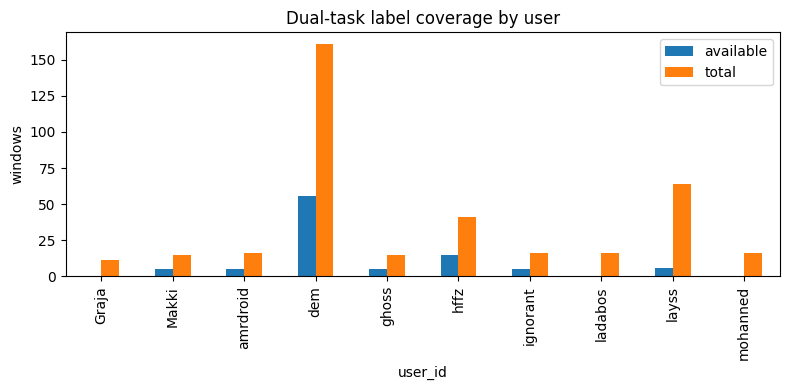

In [21]:
fig, ax = plt.subplots(figsize=(8, 4))
by_user[['available', 'total']].plot(kind='bar', ax=ax)
ax.set_title('Dual-task label coverage by user'); ax.set_ylabel('windows'); plt.tight_layout(); plt.show()

## 3. dual_task_count distribution

In [22]:
av = labels[labels['dual_task_available']]
print(av['dual_task_count'].value_counts().sort_index())
print('\nNOTE: every covered window has exactly one probe -> miss_rate is binary, RT is a single value.')

dual_task_count
1    97
Name: count, dtype: int64

NOTE: every covered window has exactly one probe -> miss_rate is binary, RT is a single value.


## 4. reaction_time_mean distribution

count      69.000000
mean     1813.203333
std       506.521812
min       900.130000
25%      1391.940000
50%      1797.840000
75%      2085.160000
max      2941.350000
Name: reaction_time_mean, dtype: float64
miss-only windows (no valid RT): 28


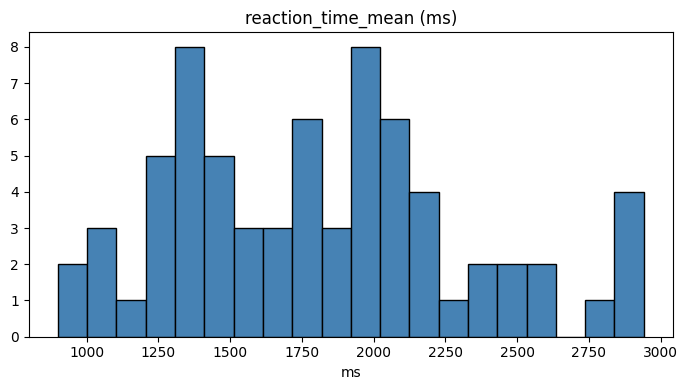

In [23]:
rt = av['reaction_time_mean'].dropna()
print(rt.describe())
print(f'miss-only windows (no valid RT): {av["reaction_time_mean"].isna().sum()}')
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(rt, bins=20, color='steelblue', edgecolor='k')
ax.set_title('reaction_time_mean (ms)'); ax.set_xlabel('ms'); plt.tight_layout(); plt.show()

## 5. reaction_time by user (boxplot)

C:\Users\medte\AppData\Local\Temp\ipykernel_4872\2339293259.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([d for _, d in data], labels=[u for u, _ in data])


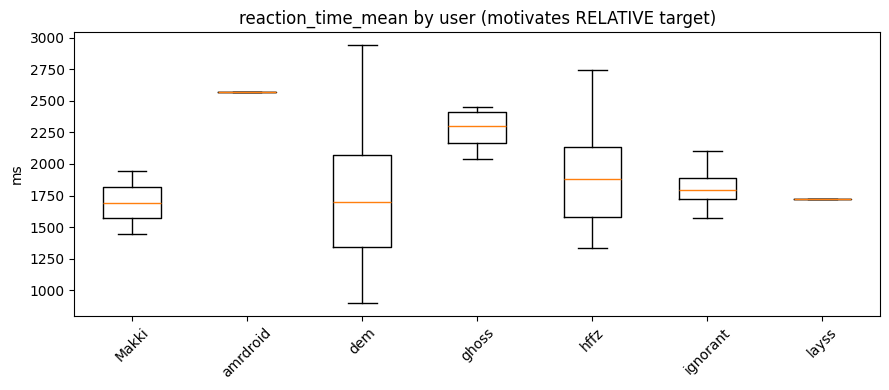

In [24]:
users = sorted(av['user_id'].unique())
data = [av[av['user_id'] == u]['reaction_time_mean'].dropna().values for u in users]
data = [(u, d) for u, d in zip(users, data) if len(d) > 0]
fig, ax = plt.subplots(figsize=(9, 4))
ax.boxplot([d for _, d in data], labels=[u for u, _ in data])
ax.set_title('reaction_time_mean by user (motivates RELATIVE target)'); ax.set_ylabel('ms')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

## 6. miss_rate / error_rate distribution

In [25]:
print('miss_rate value counts:\n', av['miss_rate'].value_counts())
print('\nerror_rate value counts:\n', av['error_rate'].value_counts())
print('\nNOTE: error_rate is 0 everywhere in this dataset -> contributes nothing to the load score.')

miss_rate value counts:
 miss_rate
0.0    70
1.0    27
Name: count, dtype: int64

error_rate value counts:
 error_rate
0.0    97
Name: count, dtype: int64

NOTE: error_rate is 0 everywhere in this dataset -> contributes nothing to the load score.


## 7. Absolute vs relative load distribution (preliminary, from label CSV)

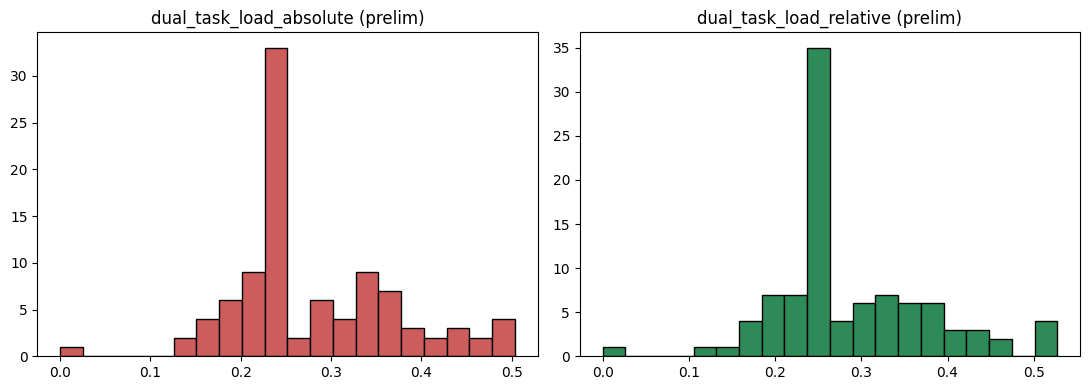

Training recomputes these with TRAIN-ONLY robust scaling to avoid leakage; CSV values are for viz only.


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(av['dual_task_load_absolute_prelim'].dropna(), bins=20, color='indianred', edgecolor='k')
axes[0].set_title('dual_task_load_absolute (prelim)')
axes[1].hist(av['dual_task_load_relative_prelim'].dropna(), bins=20, color='seagreen', edgecolor='k')
axes[1].set_title('dual_task_load_relative (prelim)')
plt.tight_layout(); plt.show()
print('Training recomputes these with TRAIN-ONLY robust scaling to avoid leakage; CSV values are for viz only.')

## 8. User imbalance

In [27]:
imb = labels.groupby('user_id').size().sort_values(ascending=False)
print('windows per user (all):\n', imb)
print('\navailable windows per user:\n', by_user['available'].sort_values(ascending=False))
print('\nUser-balanced loss (weight = 1/available_windows_per_user) counteracts dem dominating.')

windows per user (all):
 user_id
dem         161
layss        64
hffz         41
amrdroid     16
ignorant     16
ladabos      16
mohanned     16
Makki        15
ghoss        15
Graja        11
dtype: int64

available windows per user:
 user_id
dem         56
hffz        15
layss        6
Makki        5
amrdroid     5
ghoss        5
ignorant     5
Graja        0
ladabos      0
mohanned     0
Name: available, dtype: int64

User-balanced loss (weight = 1/available_windows_per_user) counteracts dem dominating.


## 9. LOSO results

In [28]:
def load_eval(d):
    p = Path(d) / 'eval_metrics.json'
    return json.loads(p.read_text()) if p.exists() else None

loso = load_eval(LOSO)
if loso:
    print('LOSO overall regression:', json.dumps(loso['overall_regression'], indent=2))
    print('beats global-mean MAE:', loso['model_beats_global_mean_mae'])
else:
    print('Run training+eval for LOSO first.')

LOSO overall regression: {
  "mae": 0.24331095747446296,
  "rmse": 0.28956941514800955,
  "pearson_r": 0.1913935138295424,
  "spearman_rho": 0.25816589522406896,
  "r2": -0.1267347376260437,
  "n": 97
}
beats global-mean MAE: True


## 10. session_within_user results

In [29]:
within = load_eval(WITHIN)
if within:
    print('WITHIN-USER overall regression:', json.dumps(within['overall_regression'], indent=2))
    print('beats global-mean MAE:', within['model_beats_global_mean_mae'])
else:
    print('Run training+eval for within-user first.')

WITHIN-USER overall regression: {
  "mae": 0.2001366965923431,
  "rmse": 0.2468222886417846,
  "pearson_r": NaN,
  "spearman_rho": -0.06640926640926641,
  "r2": -0.015390905213011008,
  "n": 36
}
beats global-mean MAE: True


## 11. Model vs baselines

In [30]:
def compare(d, name):
    ev = load_eval(d)
    bp = Path(d) / 'baselines.json'
    if not ev or not bp.exists():
        print(f'{name}: missing outputs'); return None
    base = json.loads(bp.read_text()).get('regression', {})
    rows = [{'method': 'switching_model', **{k: ev['overall_regression'].get(k) for k in ['mae','rmse','pearson_r','r2']}}]
    for k, v in base.items():
        rows.append({'method': k, 'mae': v.get('mae'), 'rmse': v.get('rmse'), 'pearson_r': v.get('pearson_r'), 'r2': v.get('r2')})
    df = pd.DataFrame(rows).set_index('method')
    print(f'=== {name} ==='); print(df.round(4)); print()
    return df

df_loso = compare(LOSO, 'LOSO')
df_within = compare(WITHIN, 'WITHIN-USER')

=== LOSO ===
                    mae    rmse  pearson_r      r2
method                                            
switching_model  0.2433  0.2896     0.1914 -0.1267
global_mean      0.2844  0.3185        NaN -0.8481
previous_window  0.2176  0.2973     0.1854 -0.6055
session_mean     0.2844  0.3185        NaN -0.8481
train_user_mean  0.2844  0.3185        NaN -0.8481

=== WITHIN-USER ===
                    mae    rmse  pearson_r      r2
method                                            
switching_model  0.2001  0.2468        NaN -0.0154
global_mean      0.2225  0.2561        NaN -0.0935
previous_window  0.2062  0.2827     0.2838 -0.3325
session_mean     0.2225  0.2561        NaN -0.0935
train_user_mean  0.2026  0.2383     0.3457  0.0534



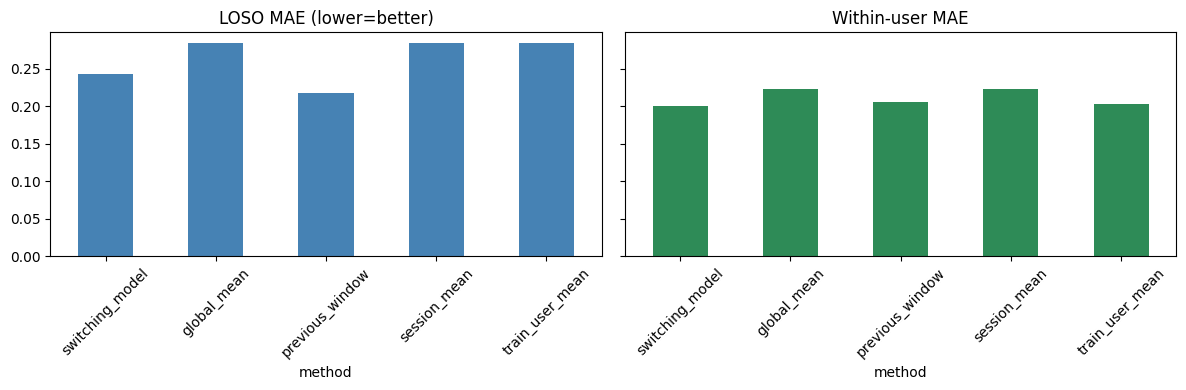

In [31]:
if df_loso is not None and df_within is not None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    df_loso['mae'].plot(kind='bar', ax=axes[0], color='steelblue'); axes[0].set_title('LOSO MAE (lower=better)')
    df_within['mae'].plot(kind='bar', ax=axes[1], color='seagreen'); axes[1].set_title('Within-user MAE')
    for ax in axes: ax.tick_params(axis='x', rotation=45)
    plt.tight_layout(); plt.show()

## 12. Prediction vs target scatter

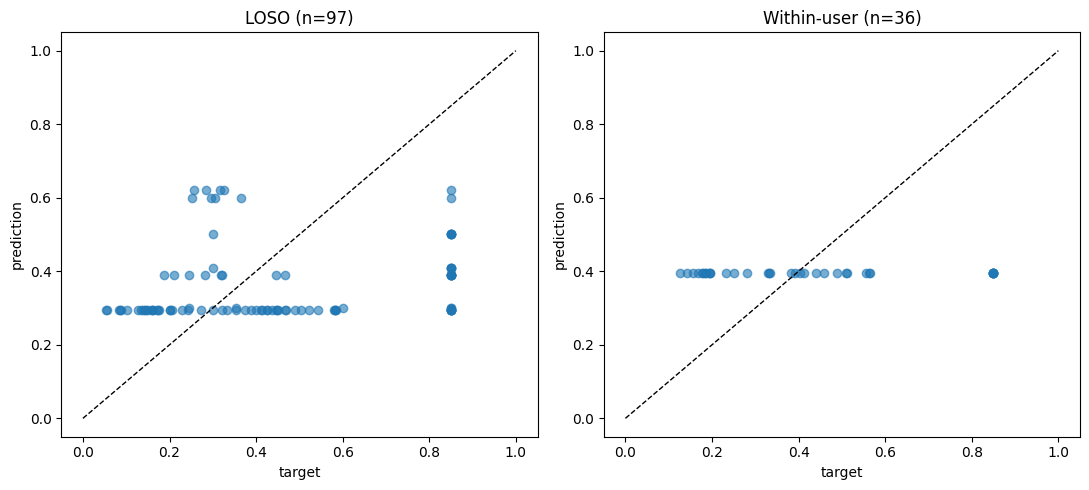

In [32]:
def scatter(d, name, ax):
    p = Path(d) / 'predictions.csv'
    if not p.exists():
        ax.set_title(f'{name}: no predictions'); return
    pr = pd.read_csv(p)
    ax.scatter(pr['target'], pr['prediction'], alpha=0.6)
    lims = [0, 1]; ax.plot(lims, lims, 'k--', lw=1)
    ax.set_xlabel('target'); ax.set_ylabel('prediction'); ax.set_title(f'{name} (n={len(pr)})')

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
scatter(LOSO, 'LOSO', axes[0]); scatter(WITHIN, 'Within-user', axes[1])
plt.tight_layout(); plt.show()

## 13. Error by user

    user_id  n_eval_windows  n_available_windows  n_missing_windows       mae      rmse  pearson_r
0     Makki               5                    5                 10  0.302231  0.374885        NaN
1  amrdroid               5                    5                 11  0.375172  0.398237        NaN
2       dem              56                   56                105  0.199594  0.249342   0.144864
3     ghoss               5                    5                 10  0.305784  0.309102        NaN
4      hffz              15                   15                 26  0.275561  0.328001        NaN
5  ignorant               5                    5                 11  0.286535  0.289323        NaN
6     layss               6                    6                 58  0.323642  0.328179        NaN


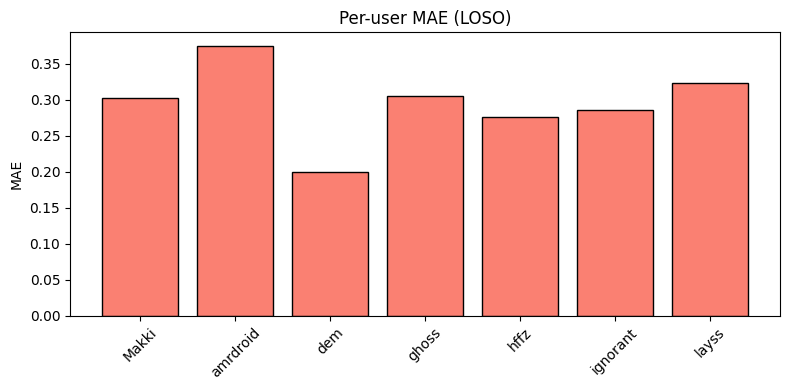

In [33]:
pu = Path(LOSO) / 'per_user_metrics.csv'
if pu.exists():
    dfu = pd.read_csv(pu)
    print(dfu)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(dfu['user_id'], dfu['mae'], color='salmon', edgecolor='k')
    ax.set_title('Per-user MAE (LOSO)'); ax.set_ylabel('MAE'); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

## 14. Error by session

In [34]:
p = Path(LOSO) / 'predictions.csv'
if p.exists():
    pr = pd.read_csv(p)
    pr['abs_error'] = pr['error'].abs()
    by_sess_err = pr.groupby('session_id')['abs_error'].agg(['mean', 'count']).sort_values('mean', ascending=False)
    print(by_sess_err)

                                    mean  count
session_id                                     
session_20260516_110318_a84820  0.375172      5
session_20260516_105315_535a79  0.355785      3
session_20260518_212527_225c72  0.329458      5
session_20260525_223533_1be900  0.323642      6
session_20260526_191020_35ca55  0.305784      5
session_20260525_214154_0a4103  0.302231      5
session_20260520_170354_7f6034  0.286535      5
session_20260520_222844_7c414b  0.255505     12
session_20260519_173652_663f90  0.237285      4
session_20260519_190457_ea6bb1  0.227591      6
session_20260517_121410_2c55a5  0.219019      6
session_20260519_182012_30aa98  0.197683      6
session_20260518_184628_9851e6  0.196772     12
session_20260517_113407_c4efba  0.162952      6
session_20260521_203934_557784  0.127899      6
session_20260518_171548_c29868  0.121747      5


## 15. Recommendations

See `DUAL_TASK_SWITCHING_SUPERVISION_REPORT.md` for the full write-up. Headline findings:

1. **Label coverage is the bottleneck.** Only ~26% of windows carry a dual-task probe, with exactly one
   probe per covered window, `miss_rate` binary, and `error_rate` always zero. Three users have zero
   coverage and cannot be evaluated under LOSO.
2. **The switching model only marginally beats the global-mean baseline** on MAE and has near-zero / negative
   R² with weak (often undefined) correlation — it largely predicts the mean.
3. **Within-user is slightly better than LOSO**, consistent with a personalization component, but neither
   produces a usable correlation given the current label density.
4. **Recommendation:** keep switching as a *weak expert* in fusion. Before trusting window-level dual-task
   supervision, collect denser probes (multiple per window) and non-zero error signals.